Question 12

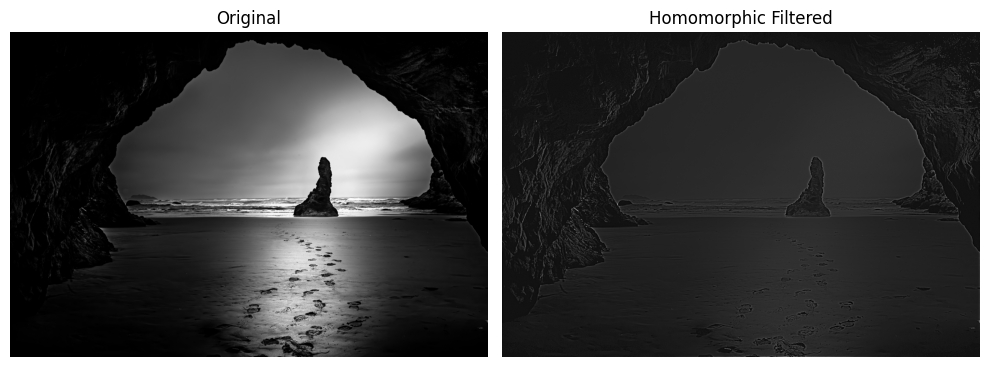

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('shadows-light.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found. Please check the path and filename.")

# Convert to float and take Log (add 1 to avoid log(0))
img_float = np.float32(img) + 1.0
log_img = np.log(img_float)

# FFT
fft = np.fft.fft2(log_img)
fft_shift = np.fft.fftshift(fft)

# Create Gaussian High-Pass Filter (Vectorized for speed)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

D0 = 80 
gamma_l = 0.5
gamma_h = 2.0

# Create a grid of coordinates
u, v = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')
D = np.sqrt((u - crow)**2 + (v - ccol)**2)

# Calculate H(u,v)
H = (gamma_h - gamma_l) * (1 - np.exp(-(D**2) / (2 * (D0**2)))) + gamma_l

# Apply Filter and Inverse FFT
filtered_fft = fft_shift * H
ifft_shift = np.fft.ifftshift(filtered_fft)
img_back = np.real(np.fft.ifft2(ifft_shift))

# Final Normalization and Exponential
# Bring img_back into a stable range before exp to prevent overflow
img_back = cv2.normalize(img_back, None, 0, 5, cv2.NORM_MINMAX) 
img_final = np.exp(img_back)

# Final stretch to 0-255 for display
img_final = cv2.normalize(img_final, None, 0, 255, cv2.NORM_MINMAX)
img_final = np.uint8(img_final)

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); 
plt.title("Original"); 
plt.imshow(img, cmap='gray'); 
plt.axis('off')

plt.subplot(1, 2, 2); 
plt.title("Homomorphic Filtered"); 
plt.imshow(img_final, cmap='gray'); 
plt.axis('off')
plt.tight_layout()
plt.show()